## Environment setup

In [120]:
from datetime import datetime 
import importlib
from functools import partial

import tensorflow as tf
from tensorflow.data import Dataset, TFRecordDataset
import tensorflow_datasets as tfds

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

# Notebooks run from VSCode use home directory as a base path
# while notebooks ran from JupyterLab use the current directory as a base path
import sys
sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")

# Change directory to the working directory
import os
os.chdir('/scratch_hdd/akalinow/ELITPC/PythonAnalysis/')

#Increase plots font size
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (10, 7),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

### Load the dataset and convert to pandas DataFrame

In [121]:
fileName = 'SimEvent_Track3D_TwoProng_gun_MC_2025-12-18T11-06.root'

In [122]:
import io_functions as io
importlib.reload(io)

dataPath = '/home/akalinow/scratch/ELITPC/TPCReco/build_with_TF/resources/'
rootFiles = [dataPath+fileName+':TPCData']

# Convert ROOT files to TF format and save to output directory
simOutputDir = 'SimEvent_Track3D_TwoProng_gun_MC_test'
io.convertROOT(rootFiles, simOutputDir, fields= io.simEventFields)

# uproot always takes the first branch with given name, unless 
# explicit branch is given as input path. Filtering by branches in
# iterate does not work. We have to give full path to the branch: TPCData/RecoEvent
rootFiles = [aFile+'/RecoEvent' for aFile in rootFiles]

# Convert ROOT files to TF format and save to output directory
recoOutputDir = 'RecoEvent_Track3D_TwoProng_gun_MC_test'
io.convertROOT(rootFiles, recoOutputDir, fields=io.recoEventFields)

# merge SimEvent and RecoEvent data

simOutputDir = 'SimEvent_Track3D_TwoProng_gun_MC_test'
recoOutputDir = 'RecoEvent_Track3D_TwoProng_gun_MC_test'

simDataset = tf.data.Dataset.load(simOutputDir, compression="GZIP")
recoDataset = tf.data.Dataset.load(recoOutputDir, compression="GZIP")

mergedDataset = tf.data.Dataset.zip((simDataset, recoDataset))
mergedDataset = mergedDataset.map(
    lambda sim, reco: {
        'sim': sim,
        'reco': reco
    }
)

# filter merged dataset
# calculate sim alpha length and select events with length > 30 mm
minAlphaLength = 30.0
mergedDataset = mergedDataset.filter(
    lambda x: tf.reduce_all(
        tf.greater(
            tf.sqrt(
                tf.math.reduce_sum(tf.square(x['sim'][1][:,0] - x['sim'][1][:,1]), axis=-1)
            ), minAlphaLength
        )
    )
)

# calculate sim alpha length and select events with length < 100 mm
maxAlphaLength = 100.0
mergedDataset = mergedDataset.filter(
    lambda x: tf.reduce_all(
        tf.less(
            tf.sqrt(
                tf.math.reduce_sum(tf.square(x['sim'][1][:,0] - x['sim'][1][:,1]), axis=-1)
            ), maxAlphaLength
        )
    )
)

# save merged dataset
outputDir = 'MergedEvent_Track3D_TwoProng_gun_MC_test'
mergedDataset.save(outputDir, compression="GZIP")

In [123]:
%%time 

import utility_functions as utils
importlib.reload(utils)

dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC_test', compression="GZIP")

data = dataset.map(lambda x: tf.reshape(x["sim"][1], (1,-1))).unbatch().as_numpy_iterator()
df_sim = pd.DataFrame(data, columns=utils.columnsXYZ)

data = dataset.map(lambda x: tf.reshape(x["reco"][1], (1,-1))).unbatch().as_numpy_iterator()
df_reco = pd.DataFrame(data, columns=utils.columnsXYZ)

df_XYZ = df_sim.merge(df_reco, left_index=True, right_index=True, suffixes=("_sim", "_reco"), how="outer");

Cause: could not parse the source code of <function <lambda> at 0x7d148dd92fc0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7d148dd92fc0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7d14f8186b60>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7d14f8186b60>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-12-23 09:47:02.189997: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


CPU times: user 3.42 s, sys: 46.7 ms, total: 3.47 s
Wall time: 3.15 s


2025-12-23 09:47:03.776063: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Load the model


tf.Tensor(
[[[ -1.8286949  23.518288   -7.294714 ]
  [ -1.0193987 -48.87894     8.342523 ]
  [-52.933636  -51.04467   -52.754265 ]]], shape=(1, 3, 3), dtype=float32)


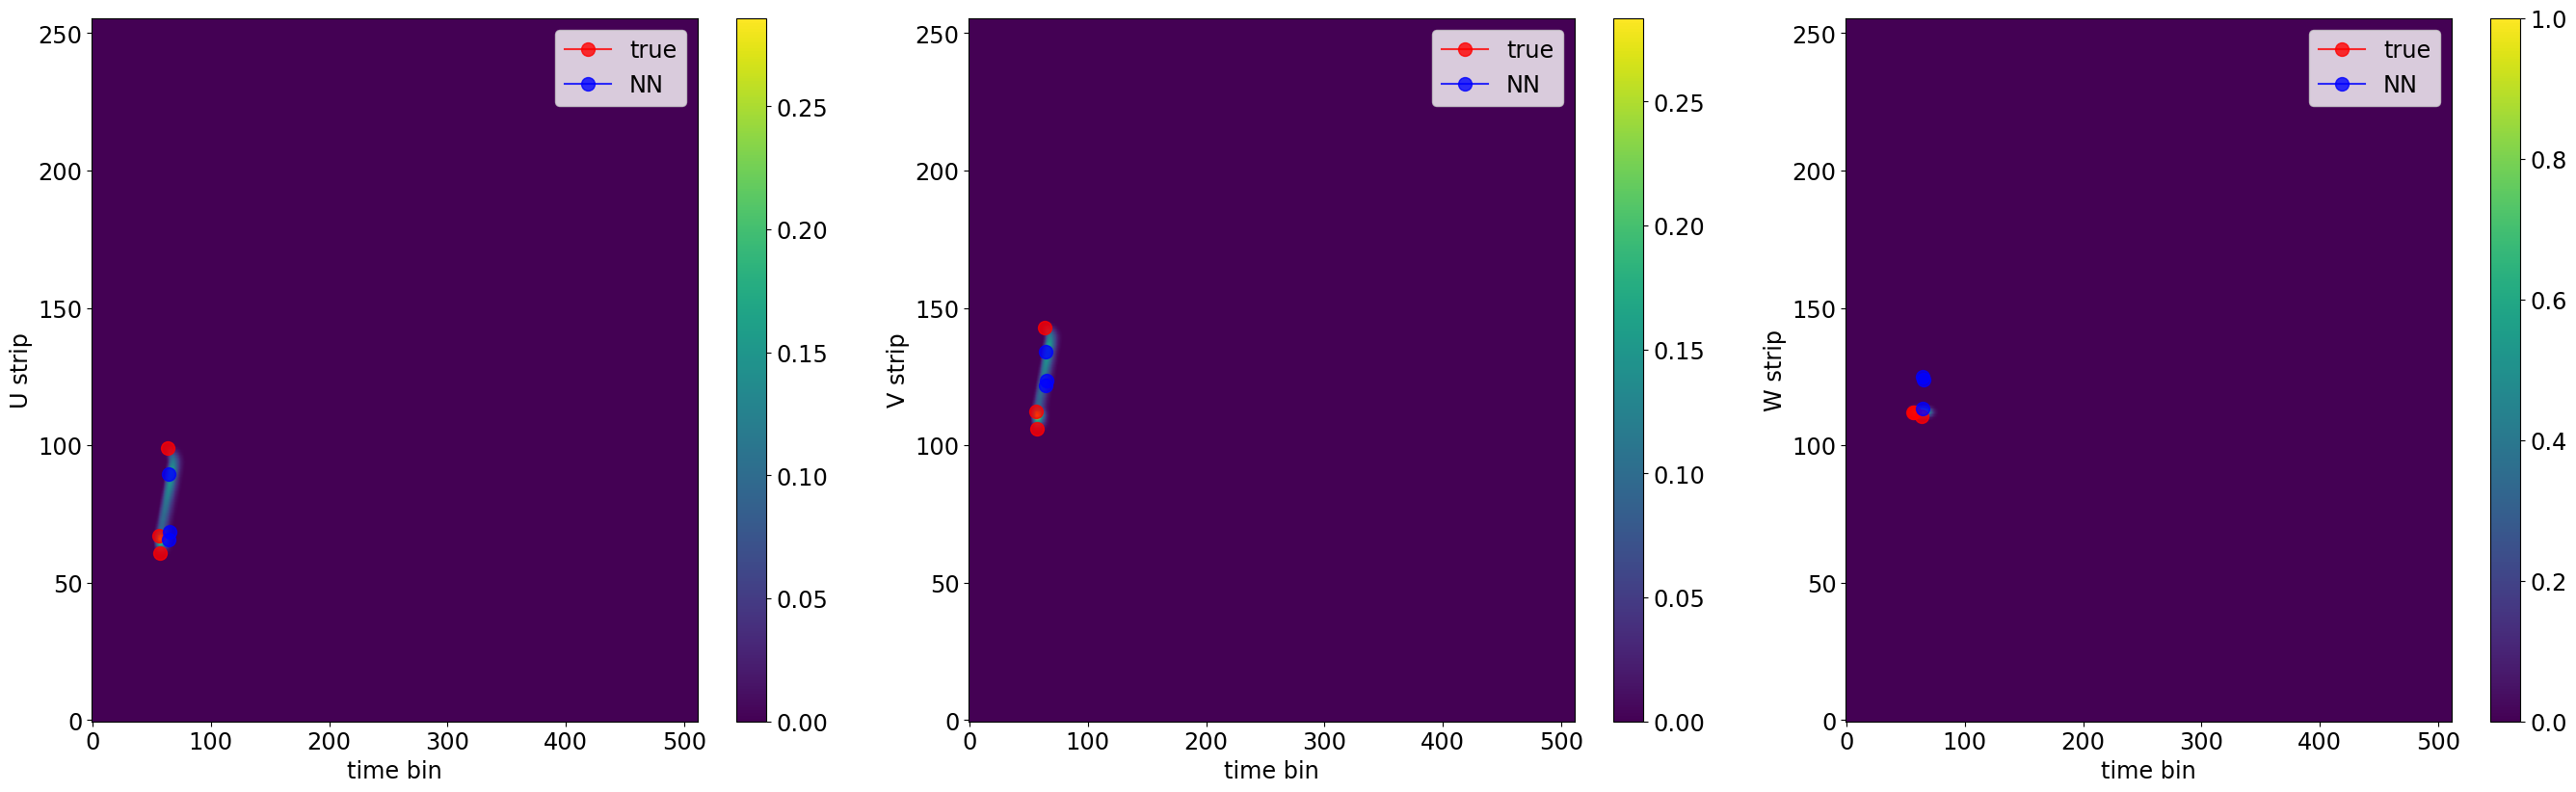

In [124]:
import plotting_functions as plf
importlib.reload(plf)

path = '/home/akalinow/scratch/ELITPC/PythonAnalysis/training/0020_2025_Dec_17_11_15_49.keras'
model = tf.keras.models.load_model(path)

x = iter(dataset.batch(1))
for i in range(1):
    item = next(x)
    plf.plotEvent(item['sim'], model=model)
    print(item['sim'][1])

### Resolution plots in XYZ

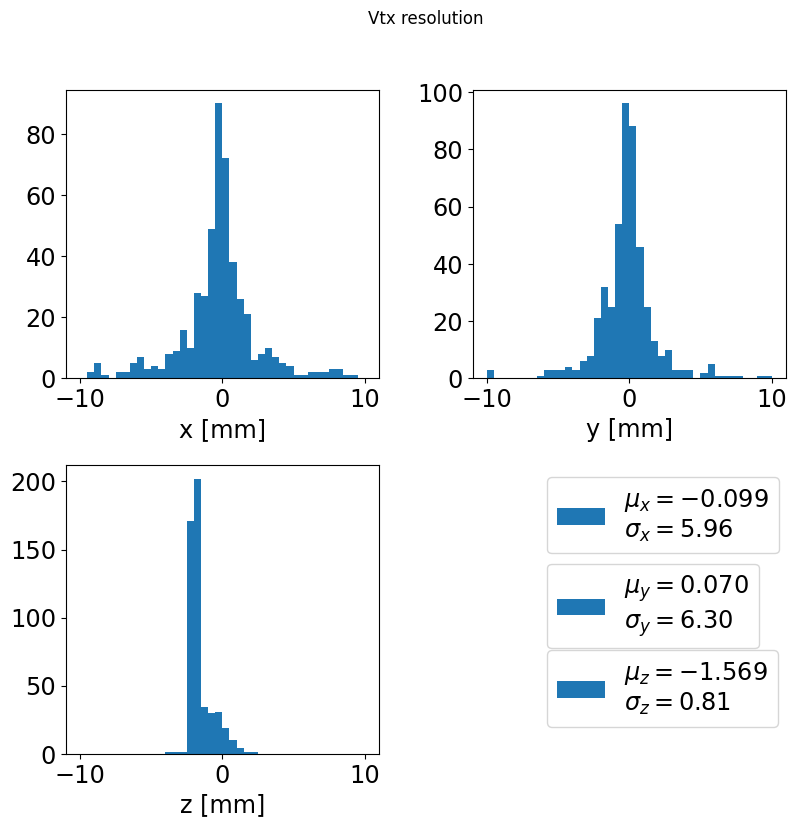

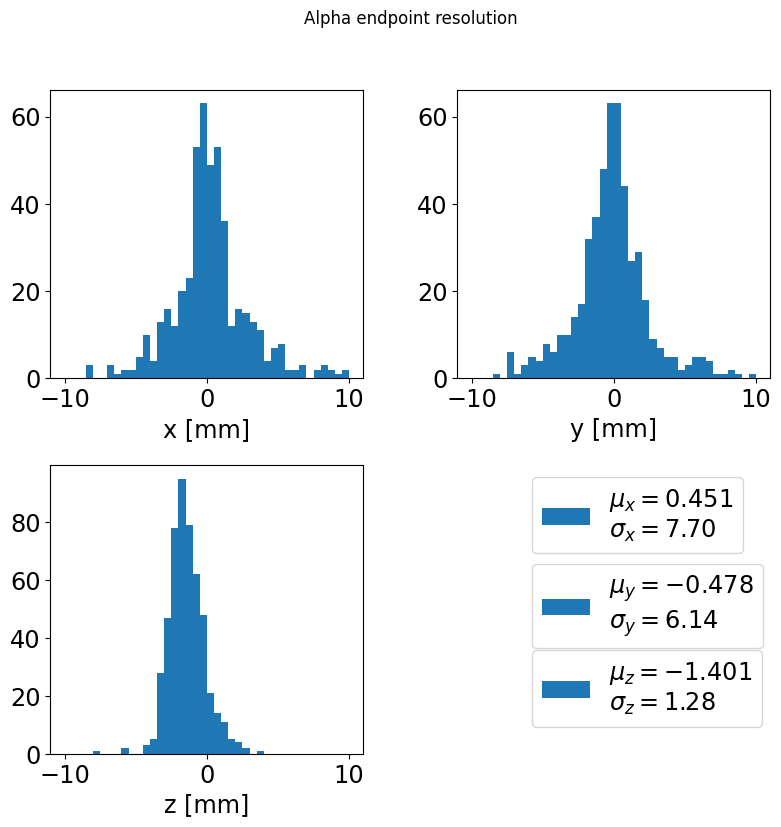

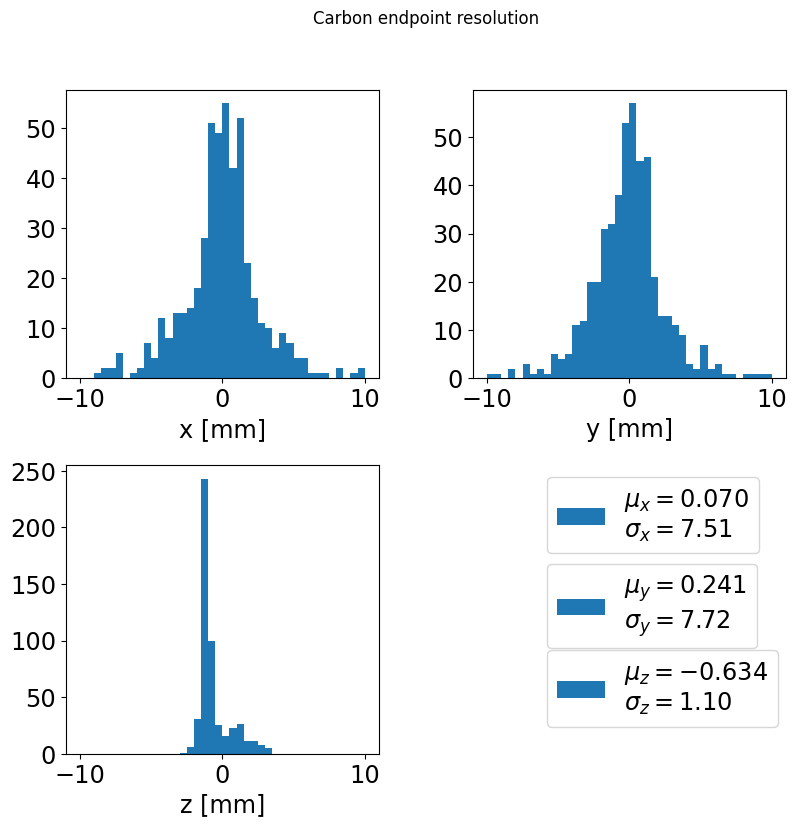

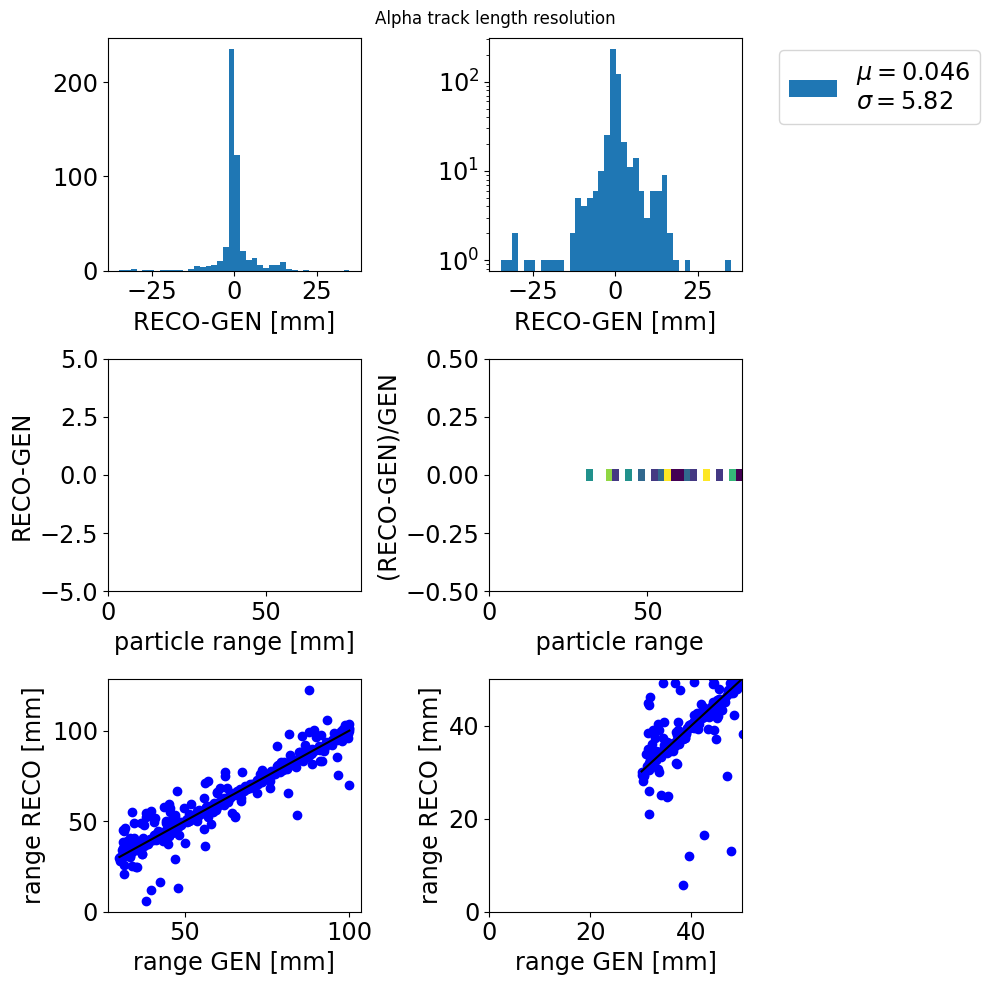

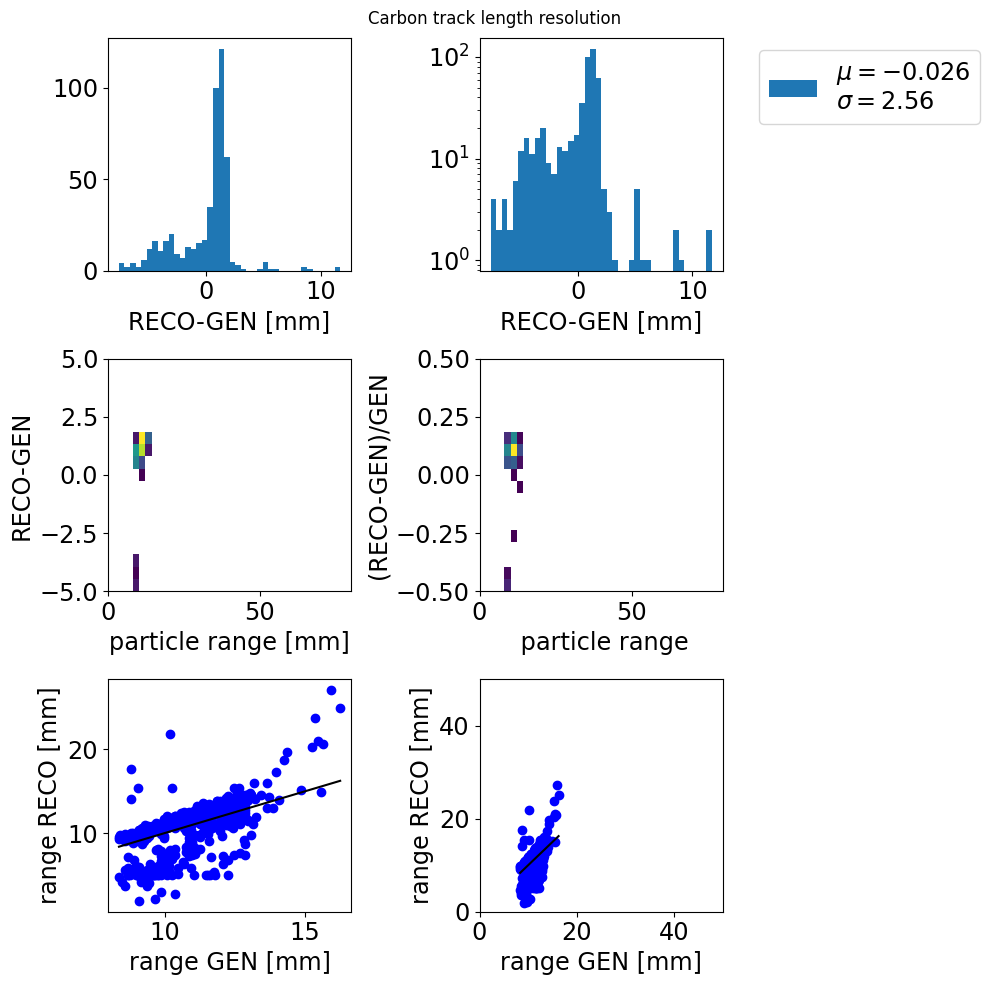

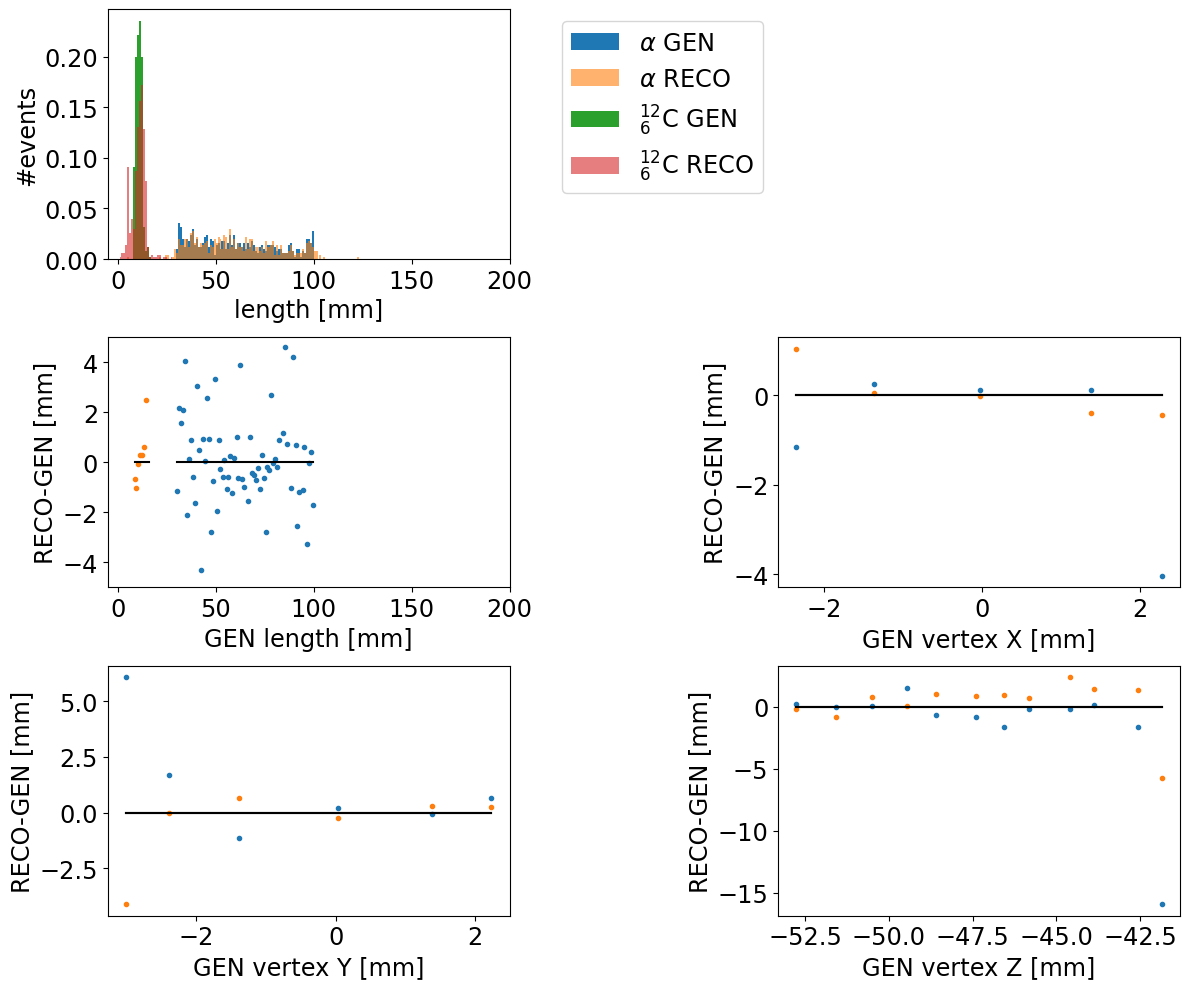

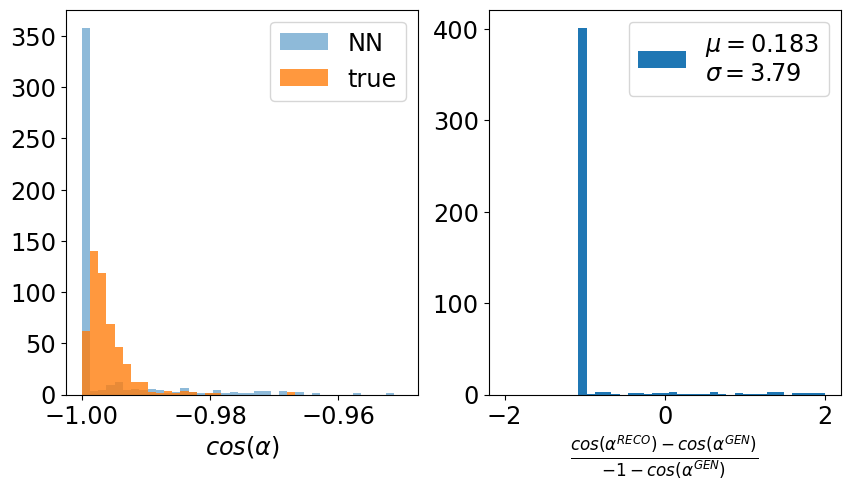

In [125]:
import plotting_functions as plf
importlib.reload(plf)

#plf.controlPlots(df)
plf.plotEndPointRes(df=df_XYZ, edge="Vtx", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df_XYZ, edge="Alpha", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df_XYZ, edge="Carbon", coordinates=["x", "y", "z"])

plf.plotLengthPull(df_XYZ, partName="Alpha")
plf.plotLengthPull(df_XYZ, partName="Carbon")
plf.plotLengthPullEvolution(df_XYZ)
plf.plotOpeningAngleCos(df_XYZ)

(-2.0, 2.0)

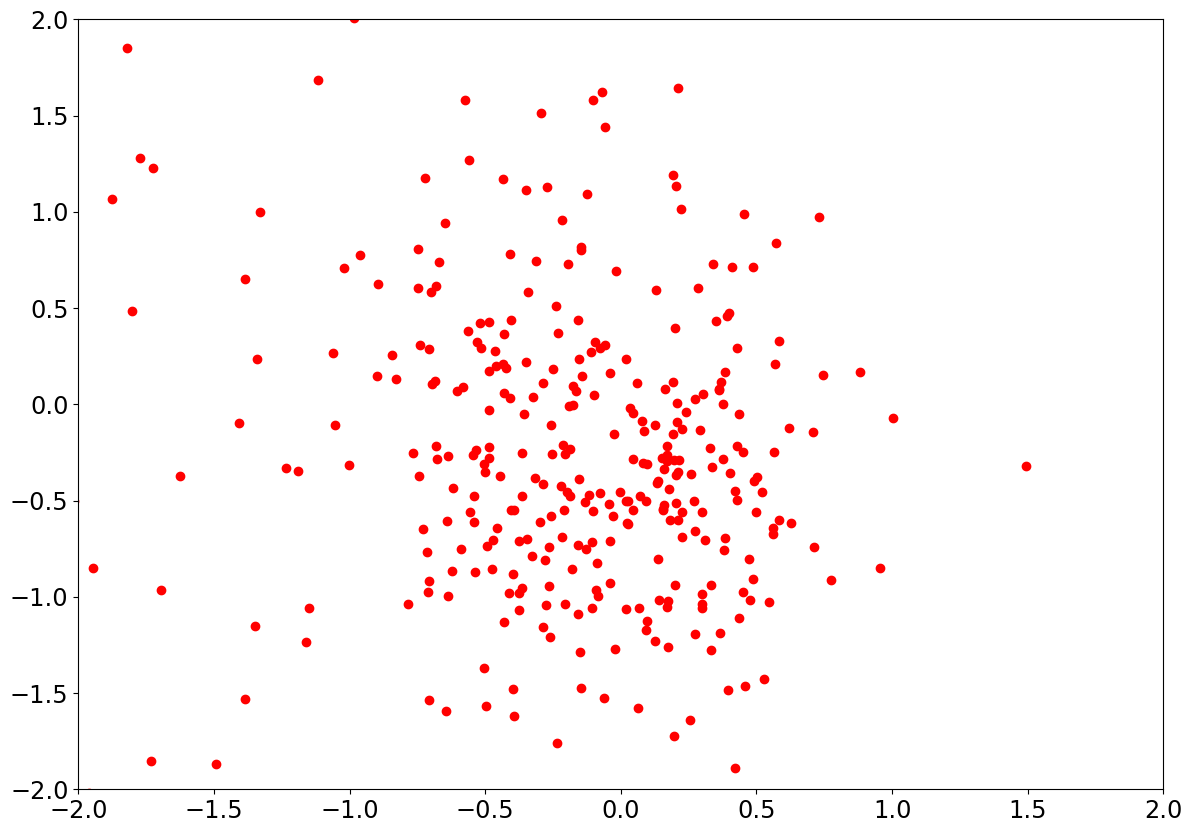

In [126]:

x = 1.25 + (0.5*df_XYZ['dCarbon_reco']-7)*(df_XYZ['dCarbon_reco']>14)
#plt.plot(df_XYZ['dCarbon_reco'], df_XYZ['pullCarbon'], "ro")
#plt.plot(df_XYZ['dCarbon_reco'], x, "go")

#plt.hist((df_XYZ['dCarbon_reco'] - x) - df_XYZ['dCarbon_sim'], bins=np.arange(-5,5,0.1));
#plt.hist(df_XYZ['dCarbon_reco'] - 1.25 - df_XYZ['dCarbon_sim'], bins=np.arange(-5,5,0.1));

plt.plot(df_XYZ['pullCarbon']-1.25, df_XYZ['pullAlpha'], "ro")
plt.xlim((-2,2))
plt.ylim((-2,2))

/tmp/ipykernel_52443/479276278.py:18: RuntimeWarning: invalid value encountered in divide
  eff = numerator / denominator
/tmp/ipykernel_52443/479276278.py:37: RuntimeWarning: invalid value encountered in divide
  eff = numerator / denominator
/tmp/ipykernel_52443/479276278.py:47: RuntimeWarning: invalid value encountered in divide
  eff = numerator / denominator


(0.0, 1.05)

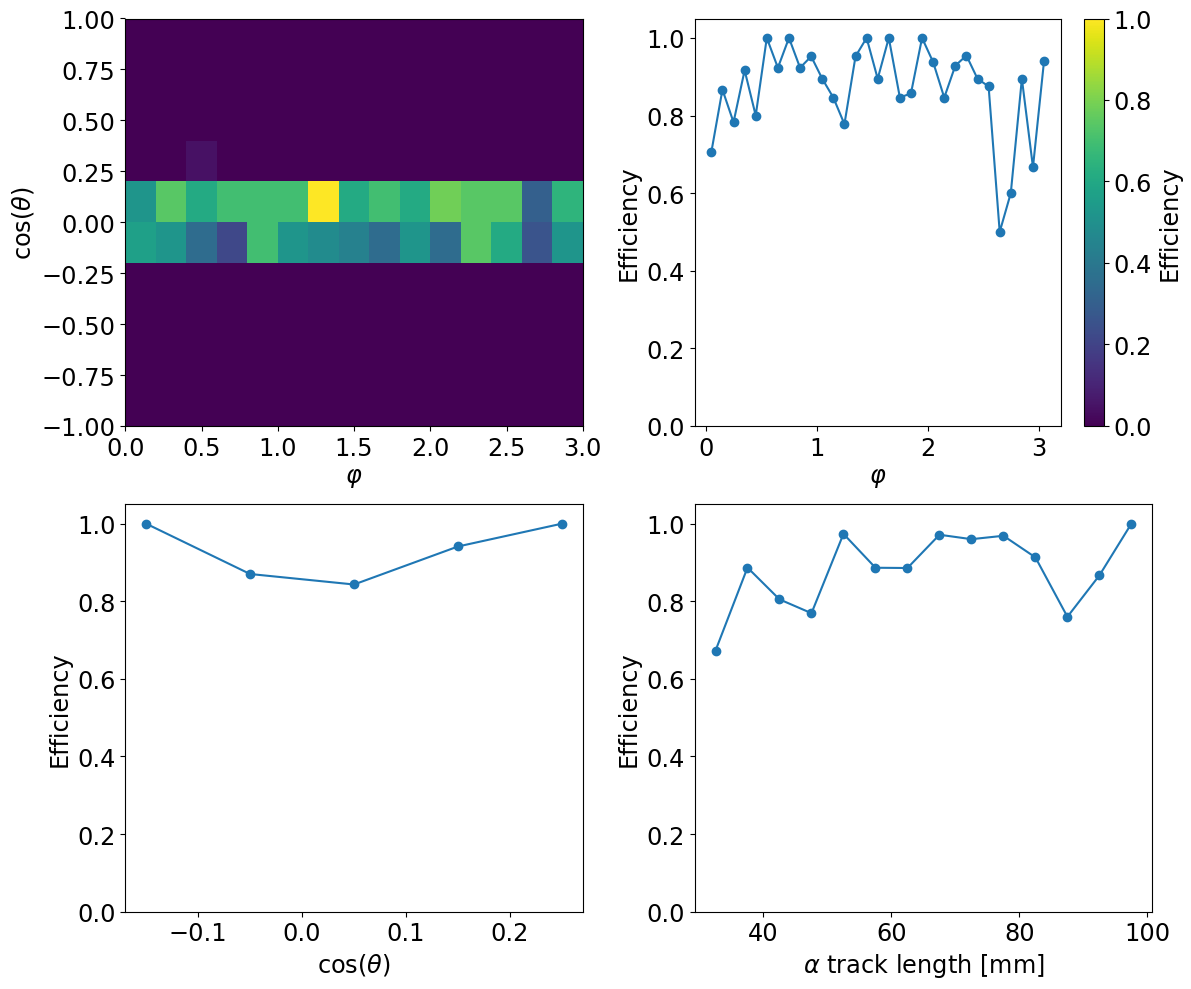

In [127]:
df_XYZ["cosTheta_sim"] = (df_XYZ["zAlpha_sim"] - df_XYZ["zVtx_sim"])/df_XYZ["dAlpha_sim"]
df_XYZ["cosPhi_sim"] = (df_XYZ["xAlpha_sim"] - df_XYZ["xVtx_sim"])/np.sqrt((df_XYZ["xAlpha_sim"] - df_XYZ["xVtx_sim"])**2 + (df_XYZ["yAlpha_sim"] - df_XYZ["yVtx_sim"])**2 )
df_XYZ["phi_sim"] = np.arccos(df_XYZ["cosPhi_sim"])

goodFiducial = (np.abs(df_XYZ["xVtx_sim"] + df_XYZ["dAlpha_sim"] * np.sqrt(1 - df_XYZ["cosTheta_sim"]**2) * np.cos(df_XYZ["phi_sim"])) < 140) & \
                (np.abs(df_XYZ["yVtx_sim"] + df_XYZ["dAlpha_sim"] * np.sqrt(1 - df_XYZ["cosTheta_sim"]**2) * np.sin(df_XYZ["phi_sim"])) < 90) & \
                (np.abs(df_XYZ["zVtx_sim"] + df_XYZ["dAlpha_sim"] * df_XYZ["cosTheta_sim"]) < 60)

goodReco = (df_XYZ["pullAlpha"]/df_XYZ["dAlpha_sim"] < 0.05)
df_good_gen = df_XYZ[goodFiducial]
df_good_reco = df_XYZ[goodReco*goodFiducial]

fig, axes = plt.subplots(2,2, figsize=(12,10), layout='tight')

#2d efficiency
denominator, _,_,_ = axes[0,0].hist2d(df_good_gen["phi_sim"], df_good_gen["cosTheta_sim"], bins=(np.arange(0, np.pi, 0.2), np.arange(-1,1.1,0.2)))
numerator, _,_,_   = axes[0,0].hist2d(df_good_reco["phi_sim"], df_good_reco["cosTheta_sim"], bins=(np.arange(0, np.pi, 0.2), np.arange(-1,1.1,0.2)))
eff = numerator / denominator
axes[0,0].imshow(eff.T, origin='lower', aspect='auto', extent=[0, np.pi, -1, 1])
axes[0,0].set_xlabel(r"$\varphi$")
axes[0,0].set_ylabel(r"$\cos(\theta)$")
fig.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axes[0,1], label='Efficiency')

# 1d versus phi
denominator, _,_ = axes[0,1].hist(df_good_gen["phi_sim"], bins=np.arange(0, np.pi, 0.1))
numerator, _,_   = axes[0,1].hist(df_good_reco["phi_sim"], bins=np.arange(0, np.pi, 0.1))
eff = numerator / denominator
axes[0,1].clear()
axes[0,1].plot((np.arange(0, np.pi, 0.1)[:-1] + np.arange(0, np.pi, 0.1)[1:])/2, eff, marker='o')
axes[0,1].set_xlabel(r"$\varphi$")
axes[0,1].set_ylabel("Efficiency")
axes[0,1].set_ylim(0, 1.05)

# 1d versus cosTheta
denominator, _,_ = axes[1,0].hist(df_good_gen["cosTheta_sim"], bins=np.arange(-1,1.1,0.1))
numerator, _,_   = axes[1,0].hist(df_good_reco["cosTheta_sim"], bins=np.arange(-1,1.1,0.1))
eff = numerator / denominator
axes[1,0].clear()
axes[1,0].plot((np.arange(-1,1.1,0.1)[:-1] + np.arange(-1,1.1,0.1)[1:])/2, eff, marker='o')
axes[1,0].set_xlabel(r"$\cos(\theta)$")
axes[1,0].set_ylabel("Efficiency")
axes[1,0].set_ylim(0, 1.05)

# 1d versus track length
denominator, _,_ = axes[1,1].hist(df_good_gen["dAlpha_sim"], bins=np.arange(0, 200, 5))
numerator, _,_   = axes[1,1].hist(df_good_reco["dAlpha_sim"], bins=np.arange(0, 200, 5))
eff = numerator / denominator
axes[1,1].clear()
axes[1,1].plot((np.arange(0, 200, 5)[:-1] + np.arange(0, 200, 5)[1:])/2, eff, marker='o')
axes[1,1].set_xlabel(r"$\alpha$ track length [mm]")
axes[1,1].set_ylabel("Efficiency")
axes[1,1].set_ylim(0, 1.05)


### Resolution plots in UVWT

In [128]:
import utility_functions as utils
importlib.reload(utils)

batchSize = 32
dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC_test', compression="GZIP")

data = dataset.map(lambda x: tf.reshape(x["sim"][1], (1,-1)))
data = data.map(lambda x: tf.reshape(x, (-1,3,3)))
data = data.map(lambda x: utils.XYZtoUVWT_event(x))
data = data.map(lambda x: tf.reshape(x, (-1,12))).unbatch().as_numpy_iterator()

df_sim = pd.DataFrame(data, columns=utils.columnsUVWT)

data = dataset.map(lambda x: tf.reshape(x["reco"][1], (1,-1)))
data = data.map(lambda x: tf.reshape(x, (-1,3,3)))
data = data.map(lambda x: utils.XYZtoUVWT_event(x))
data = data.map(lambda x: tf.reshape(x, (-1,12))).unbatch().as_numpy_iterator()
df_reco = pd.DataFrame(data, columns=utils.columnsUVWT)

df_UVWT = df_sim.merge(df_reco, left_index=True, right_index=True, suffixes=("_sim", "_reco"), how="outer");

2025-12-23 09:47:15.615399: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-12-23 09:47:17.331896: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


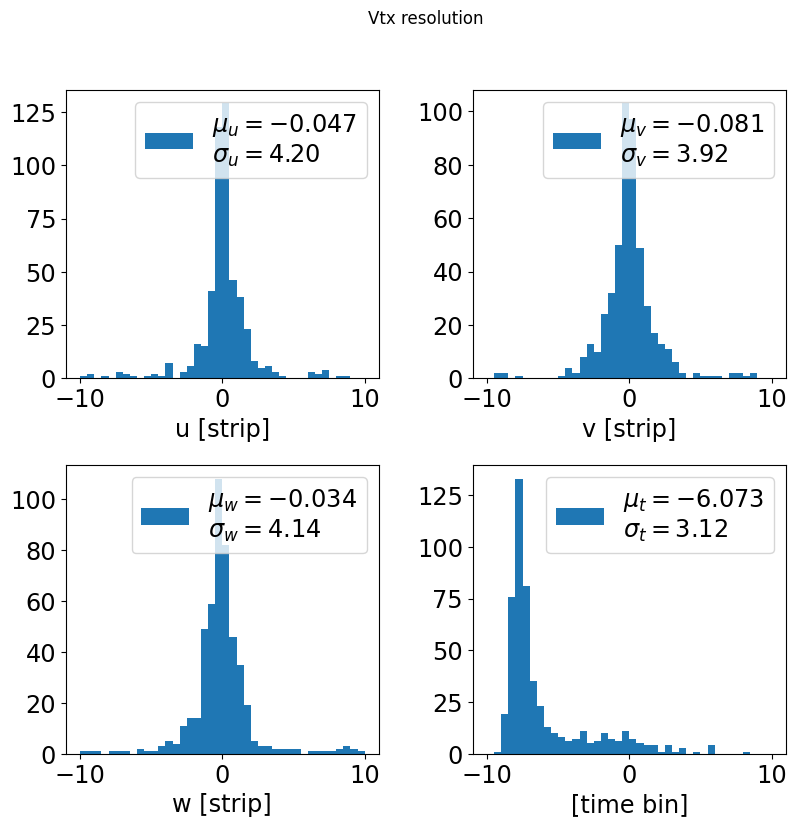

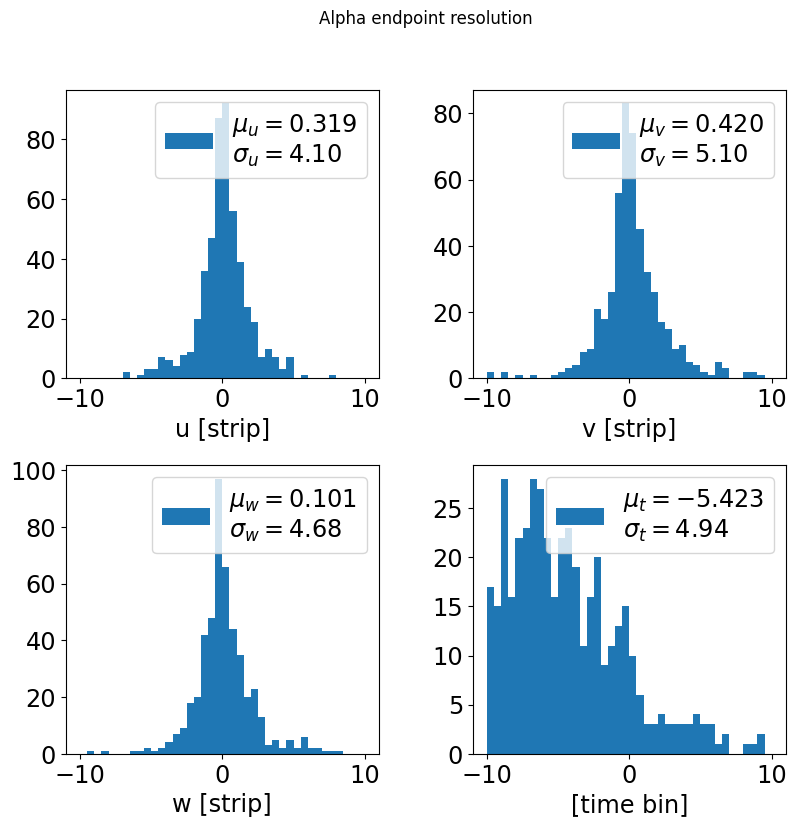

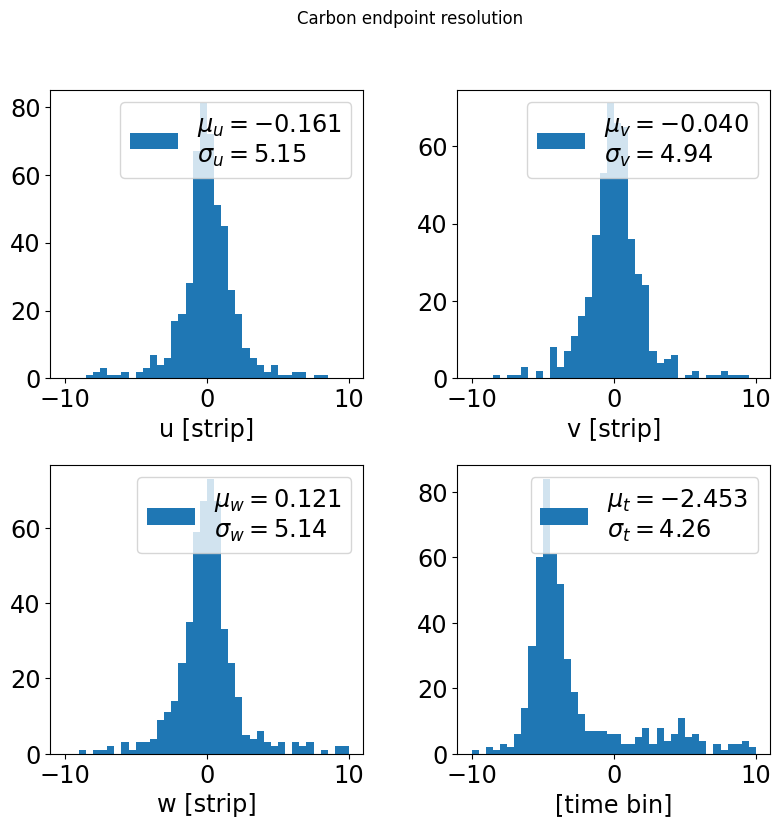

In [129]:
import plotting_functions as plf
importlib.reload(plf)

plf.plotEndPointRes(df=df_UVWT, edge="Vtx", coordinates=["u", "v", "w", "t"])
plf.plotEndPointRes(df=df_UVWT, edge="Alpha", coordinates=["u", "v", "w", "t"])
plf.plotEndPointRes(df=df_UVWT, edge="Carbon", coordinates=["u", "v", "w", "t"])